In [87]:
import numpy as np
import matplotlib.pyplot as plt

(-5.0, 5.0)

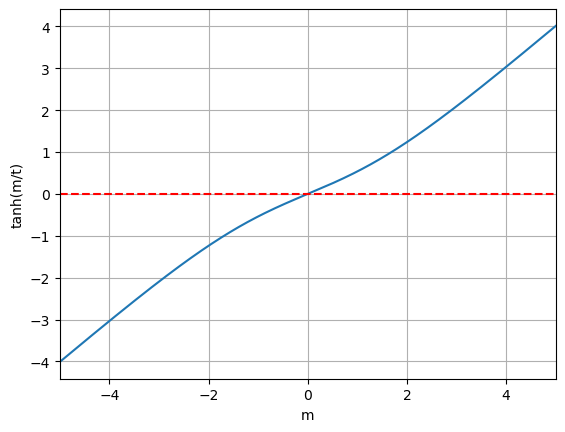

In [108]:
#SETTING UP FUNCTION
t=2.0
def function(m,t):
    return m-np.tanh(m/t)

m=np.linspace(-5,5,400)
f=lambda x: function(m,t)

fig,ax=plt.subplots()
func=function(m,t)
ax.plot(m,func)
ax.axhline(0, linestyle="--", color="r")
ax.set(
    xlabel="m",
    ylabel="tanh(m/t)"
)
ax.grid()
ax.set_xlim(-5,5)

In [100]:
def g(m):
    return np.tanh(m/t)

def fixedpoint(g,x_old,k_max=200,tol=1.e-8):
    for k in range(1,k_max):
        x_new=g(x_old)

        x_diff=x_new-x_old
        print("{0:2d} {1:1.16f} {2:1.16f}".format(k,x_new,x_diff))

        if abs(x_diff/x_new)<tol:
            break

        x_old=x_new
    else:
        x_new=None

    return x_new

In [101]:
#for t>1, there is only one root
for x_old in (-2.5,2.5):
    x_roots=fixedpoint(g,x_old)
    print(x_roots)

 1 -0.8482836399575129 1.6517163600424871
 2 -0.4004139457741510 0.4478696941833619
 3 -0.1975742219374505 0.2028397238367005
 4 -0.0984670094869245 0.0991072124505260
 5 -0.0491937636208592 0.0492732458660653
 6 -0.0245919225853361 0.0246018410355231
 7 -0.0122953416519570 0.0122965809333791
 8 -0.0061475933790861 0.0061477482728709
 9 -0.0030737870089376 0.0030738063701485
10 -0.0015368922944011 0.0015368947145365
11 -0.0007684459959424 0.0007684462984588
12 -0.0003842229790639 0.0003842230168784
13 -0.0001921114871685 0.0001921114918954
14 -0.0000960557432888 0.0000960557438797
15 -0.0000480278716075 0.0000480278716814
16 -0.0000240139357991 0.0000240139358084
17 -0.0000120069678990 0.0000120069679001
18 -0.0000060034839494 0.0000060034839496
19 -0.0000030017419747 0.0000030017419747
20 -0.0000015008709873 0.0000015008709874
21 -0.0000007504354937 0.0000007504354937
22 -0.0000003752177468 0.0000003752177468
23 -0.0000001876088734 0.0000001876088734
24 -0.0000000938044367 0.000000093

In [102]:
#BISECTION METHOD
def bisection(f,x0,x1,k_max=200,tol=1.e-8):
    f0=function(x0,t)
    for k in range(1,k_max):
        x2=(x0+x1)/2
        f2=function(x2,t)

        if f0*f2<0:
            x1=x2
        else:
            x0,f0=x2,f2

        x2_new=(x0+x1)/2
        xdiff=abs(x2_new-x2)
        rowf="{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}"
        print(rowf.format(k,x2_new,xdiff,abs(function(x2_new,t))))

        if abs(xdiff/x2_new)<tol:
            break
    else:
        x2_new=None

    return x2_new

In [103]:
#root
root=bisection(f,-2.5,2.5)
print(root); print("")

 1 1.2500000000000000 1.2500000000000000 0.6954002776506177
 2 1.8750000000000000 0.6250000000000000 1.1409284803956585
 3 2.1875000000000000 0.3125000000000000 1.3892572454601131
 4 2.3437500000000000 0.1562500000000000 1.5188776790461174
 5 2.4218750000000000 0.0781250000000000 1.5849145119494379
 6 2.4609375000000000 0.0390625000000000 1.6182222623682030
 7 2.4804687500000000 0.0195312500000000 1.6349463226341205
 8 2.4902343750000000 0.0097656250000000 1.6433256321671608
 9 2.4951171875000000 0.0048828125000000 1.6475195735496397
10 2.4975585937500000 0.0024414062500000 1.6496176117488970
11 2.4987792968750000 0.0012207031250000 1.6506668972078180
12 2.4993896484375000 0.0006103515625000 1.6511916064624215
13 2.4996948242187500 0.0003051757812500 1.6514539777129262
14 2.4998474121093750 0.0001525878906250 1.6515851674929687
15 2.4999237060546875 0.0000762939453125 1.6516507634215616
16 2.4999618530273438 0.0000381469726562 1.6516835616454850
17 2.4999809265136719 0.0000190734863281

In [112]:
!!!#NEWTON'S METHOD
def func_newton(m,t):
    return float(m-np.tanh(m/t))

def sech(x):
    return 1/np.cosh(x)

sech=sech(m/t)

def newtons(f,x0,x1,k_max=200,tol=1.e-8):
    f0=func_newton(x0,t)
    for k in range(1,k_max):
        f1=func_newton(x1,t)
        f1prime=1-(1/t)*(sech)**2
        ratio=f1/f1prime
        x2=x1-ratio

        xdiff=abs(x2-x1)
        x0,x1=x1,x2
        f0=f1

        rowf="{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}"
        print(rowf.format(k, x2, xdiff, abs(func_newton(x2, t))))

        if abs(xdiff/x2)<tol:
            break

    else:
        x2=None

    return x2

In [113]:
#root
root=newtons(f,-2.5,2.5)
print(root); print("")

TypeError: only length-1 arrays can be converted to Python scalars

In [106]:
root = newtons(lambda x: function(x, t), -2.5, 2.5)
print(root); print("")

TypeError: only length-1 arrays can be converted to Python scalars